In [1]:
import torch.nn as nn
import torch
from torchvision import datasets, transforms
import torchvision

from torch.utils.data import DataLoader

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


device(type='cuda')

In [3]:
config = {

          "patch_size": 7,
          "num_channle": 1,
          "img_size" : 28,
          "batch_size": 64,
          "emmding_dim": 64,
          "num_patch": 16,
          "dropout":0,
          "Att_head":4,
          "qkv_bias":True,
          "num_layer":4,
          "num_classes":10


}

In [4]:
train_dataset = datasets.MNIST(root = "./data", train=True, download=True , transform=torchvision.transforms.ToTensor())
test_dataset = datasets.MNIST(root = "./data", train=False, download=True, transform=torchvision.transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.98MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.48MB/s]


In [5]:
train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=config["batch_size"], shuffle=True)

In [6]:
class Patch_Embeddings(nn.Module):
  def __init__(self,config):
    super().__init__()

    self.image_size = config["img_size"]
    self.patch_size = config["patch_size"]
    self.num_channle = config["num_channle"]
    self.embedding_dim = config["emmding_dim"]
    self.num_patches = (self.image_size // self.patch_size) ** 2

    self.patch = nn.Conv2d(self.num_channle, self.embedding_dim, kernel_size=self.patch_size, stride=self.patch_size )

  def forward(self,x):

    x = self.patch(x)
    x = x.flatten(2)
    x = x.transpose(1,2)
    return x



In [7]:
class Embeddings(nn.Module):
  def __init__(self,config):
    super().__init__()

    self.Patch_Embeddings = Patch_Embeddings(config)
    self.cls_token = nn.Parameter(torch.randn(1,1,config["emmding_dim"]))
    self.pos_embedding = nn.Parameter(torch.randn(1,1+config["num_patch"],config["emmding_dim"]))
    self.dropout = nn.Dropout(config["dropout"])

  def forward(self,x):

    x = self.Patch_Embeddings(x)
    batch_size,_,_ = x.size()
    cls_tokens = self.cls_token.expand(batch_size, -1, -1)
    x = torch.cat((cls_tokens, x), dim=1)
    x = x + self.pos_embedding
    x = self.dropout(x)
    return x




In [8]:
class Multi_Head_Attion(nn.Module):
     def __init__(self,config):
      super().__init__()

      self.dim_out = config["emmding_dim"]
      self.n_head = config["Att_head"]
      self.dim_head = self.dim_out // self.n_head
      self.W_query = nn.Linear(self.dim_out, self.dim_out, bias = config["qkv_bias"])
      self.W_key = nn.Linear(self.dim_out, self.dim_out, bias = config["qkv_bias"])
      self.W_values = nn.Linear(self.dim_out, self.dim_out, bias = config["qkv_bias"])
      self.dropout = nn.Dropout(config["dropout"])
      self.W_O = nn.Linear(self.dim_out, self.dim_out)

     def forward(self,x):
      batch_size, patch, d_in = x.shape
      query = self.W_query(x)
      key = self.W_key(x)
      values = self.W_values(x)

      query = query.view(batch_size, patch, self.n_head, self.dim_head)
      key = key.view(batch_size, patch, self.n_head, self.dim_head)
      values = values.view(batch_size, patch, self.n_head, self.dim_head)

      query = query.transpose(1,2)
      key = key.transpose(1,2)
      values = values.transpose(1,2)

      scores = torch.matmul(query, key.transpose(2,3))
      scores = scores / (self.dim_head ** 0.5)

      scores = torch.softmax(scores, dim=-1)
      scores = self.dropout(scores)

      out = torch.matmul(scores, values).transpose(1,2).contiguous().view(batch_size, patch, self.dim_out)
      out = self.W_O(out)
      return out





In [9]:
class LayerNorm(nn.Module):
  def __init__(self,config):
    super().__init__()
    self.eps = 1e-5
    self.dim_out = config["emmding_dim"]
    self.scale = nn.Parameter(torch.ones(config["emmding_dim"]))
    self.shift = nn.Parameter(torch.zeros(config["emmding_dim"]))

  def forward(self,x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False)
    norm_x = (x - mean) / torch.sqrt(var + self.eps)
    return self.scale * norm_x + self.shift


In [10]:
class FeedForward(nn.Module):
  def __init__(self,config):
    super().__init__()

    self.layer = nn.Sequential(
        nn.Linear(config["emmding_dim"], 4 * config["emmding_dim"]),
        nn.GELU(),
        nn.Linear(4 * config["emmding_dim"], config["emmding_dim"])
    )
    self.dropout = nn.Dropout(config["dropout"])

  def forward(self,x):
    x = self.layer(x)
    x = self.dropout(x)
    return x



In [11]:
class Transformer_Block(nn.Module):
  def __init__(self,config):
    super().__init__()
    self.layer_norm1 = LayerNorm(config)
    self.layer_norm2 = LayerNorm(config)
    self.Multi_Head_Attion = Multi_Head_Attion(config)
    self.MLP = FeedForward(config)

  def forward(self,x):
    shortcut = x
    x = self.layer_norm1(x)
    x = self.Multi_Head_Attion(x)
    x = shortcut + x
    shortcut = x

    x = self.layer_norm2(x)
    x = self.MLP(x)
    x = shortcut + x

    return x

In [12]:
class Transformer_Encoder(nn.Module):
  def __init__(self,config):
    super().__init__()
    self.block = nn.ModuleList([Transformer_Block(config) for _ in range(config["num_layer"])])

    # self.block = nn.ModuleList([])
    # for _ in range(config["num_layer"]):
    #   self.block.append(Transformer_Block(config))

  def forward(self,x):
    for block in self.block:
      x = block(x)

    return x


In [13]:
class VisionTranformer(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.Embeddings = Embeddings(config)
    # self.Transformer_Block = nn.Sequential(*[Transformer_Block(config) for _ in range(config["num_layer"])])
    self.Transformer_Block = Transformer_Encoder(config)
    self.Norm = LayerNorm(config)
    self.Final_Layer = nn.Linear(config["emmding_dim"], config["num_classes"])

  def forward(self,x):
    x = self.Embeddings(x)
    x = self.Transformer_Block(x)
    x = self.Norm(x)
    x = x[:,0,:]
    logits = self.Final_Layer(x)
    return logits


In [18]:
model = VisionTranformer(config)
epochs = 15


In [19]:
import torch
from tqdm import tqdm

def train_model(
    model,
    train_loader,
    val_loader,
    epochs,
    device,
    lr=3e-4
):

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs
    )

    model.to(device)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": []
    }

    for epoch in range(epochs):

        # -------------------
        # TRAIN
        # -------------------
        model.train()

        train_loss = 0
        correct = 0
        total = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for images, labels in loop:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(images)

            loss = criterion(logits, labels)

            loss.backward()

            # important for transformers
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            train_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix(loss=loss.item())

        train_acc = correct / total
        train_loss /= len(train_loader)

        # -------------------
        # VALIDATION
        # -------------------
        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                logits = model(images)

                loss = criterion(logits, labels)

                val_loss += loss.item()

                preds = torch.argmax(logits, dim=1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total
        val_loss /= len(val_loader)

        scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        print(
            f"\nEpoch {epoch+1}/{epochs}"
            f" | Train Loss: {train_loss:.4f}"
            f" | Train Acc: {train_acc:.4f}"
            f" | Val Loss: {val_loss:.4f}"
            f" | Val Acc: {val_acc:.4f}"
            f" | LR: {current_lr:.6f}"
        )



In [20]:
train_model(model=model, train_loader=train_loader, val_loader=test_loader, epochs=epochs, device=device)

Epoch 1/15: 100%|██████████| 938/938 [00:24<00:00, 37.68it/s, loss=0.081]



Epoch 1/15 | Train Loss: 0.5812 | Train Acc: 0.8159 | Val Loss: 0.2215 | Val Acc: 0.9335 | LR: 0.000297


Epoch 2/15: 100%|██████████| 938/938 [00:25<00:00, 37.43it/s, loss=0.132]



Epoch 2/15 | Train Loss: 0.1685 | Train Acc: 0.9496 | Val Loss: 0.1283 | Val Acc: 0.9609 | LR: 0.000287


Epoch 3/15: 100%|██████████| 938/938 [00:25<00:00, 37.43it/s, loss=0.0283]


...


Epoch 13/15 | Train Loss: 0.0104 | Train Acc: 0.9974 | Val Loss: 0.0611 | Val Acc: 0.9843 | LR: 0.000013


Epoch 14/15: 100%|██████████| 938/938 [00:25<00:00, 36.67it/s, loss=0.00395]



Epoch 14/15 | Train Loss: 0.0083 | Train Acc: 0.9982 | Val Loss: 0.0626 | Val Acc: 0.9836 | LR: 0.000003


Epoch 15/15: 100%|██████████| 938/938 [00:25<00:00, 36.45it/s, loss=0.00136]



Epoch 15/15 | Train Loss: 0.0073 | Train Acc: 0.9984 | Val Loss: 0.0616 | Val Acc: 0.9841 | LR: 0.000000


In [21]:
import torch
import matplotlib.pyplot as plt

def predict_and_show(model, loader, device, num_images=10):

    model.eval()

    images, labels = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        logits = model(images)
        preds = torch.argmax(logits, dim=1)

    images = images.cpu()

    plt.figure(figsize=(12,5))

    for i in range(num_images):

        plt.subplot(2,5,i+1)

        img = images[i].squeeze()

        plt.imshow(img, cmap="gray")

        pred = preds[i].item()
        true = labels[i].item()

        plt.title(f"Pred: {pred} | True: {true}")

        plt.axis("off")

    plt.tight_layout()
    plt.show()

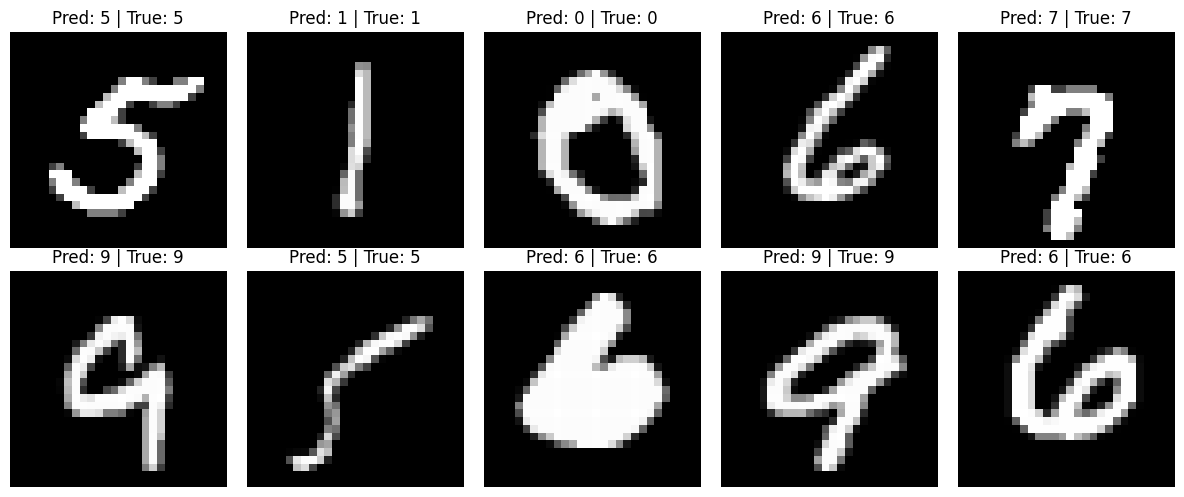

In [29]:
predict_and_show(model=model, loader=test_loader, device=device)
